In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read CSV file and store in variable name 'df'

df = pd.read_csv("/content/Amazon Product Reviews.csv")
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30846 entries, 0 to 30845
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        30846 non-null  object
 1   customer_id        30846 non-null  int64 
 2   review_id          30846 non-null  object
 3   product_id         30846 non-null  object
 4   product_parent     30846 non-null  int64 
 5   product_title      30846 non-null  object
 6   product_category   30846 non-null  object
 7   star_rating        30846 non-null  int64 
 8   helpful_votes      30846 non-null  int64 
 9   total_votes        30846 non-null  int64 
 10  vine               30846 non-null  object
 11  verified_purchase  30846 non-null  object
 12  review_headline    30844 non-null  object
 13  review_body        30842 non-null  object
 14  review_date        30846 non-null  object
 15  sentiment          30846 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 3.

In [4]:
df.describe()

,customer_id,product_parent,star_rating,helpful_votes,total_votes,sentiment
count,3.084600e+04,30846.0,30846.000000,30846.00000,30846.000000,30846.000000
mean,2.471002e+07,2693241.0,4.336154,0.68641,0.895027,0.835343
std,1.611172e+07,0.0,1.120716,30.74337,32.356354,0.370876
min,1.134600e+04,2693241.0,1.000000,0.00000,0.000000,0.000000
25%,1.150637e+07,2693241.0,4.000000,0.00000,0.000000,1.000000
50%,2.294025e+07,2693241.0,5.000000,0.00000,0.000000,1.000000
75%,4.008874e+07,2693241.0,5.000000,0.00000,0.000000,1.000000
max,5.309351e+07,2693241.0,5.000000,3720.00000,3875.000000,1.000000


In [5]:
df.isnull().sum()

,0
marketplace,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0
total_votes,0


In [6]:
df = df.dropna(subset = ['review_headline', 'review_body'])
df.isnull().sum()

,0
marketplace,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0
total_votes,0


In [7]:
# DATA CLEANING

import re
import string

def clean_review(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()                                             # converts text into lowercase
    text = re.sub(r'<[^>]+>', ' ', text)                            # converts all HTML into spaces. eg:- <br/>
    text = re.sub(r'[^a-zA-Z\s]', '', text)                         # converts all the emojis, special characters into space (^ inside brackets means NOT alphabets or space)
    text = re.sub(r'\s+', ' ', text).strip()                        # converts extra spaces into single space, strip() cuts out all the extra spaces present at the very beggining or at very last
    return text

df['cleaned_review'] = df['review_body'].apply(clean_review)
df[['review_body', 'cleaned_review']].head()

,review_body,cleaned_review
0,Great love it,great love it
1,Lots of ads<br />Slow processing speed<br />Oc...,lots of ads slow processing speed occasionally...
2,Excellent unit. The versatility of this table...,excellent unit the versatility of this tablet ...
3,I bought this on Amazon Prime so I ended up bu...,i bought this on amazon prime so i ended up bu...
4,All Amazon products continue to meet my expect...,all amazon products continue to meet my expect...


In [8]:
rating_counts = df['star_rating'].value_counts().sort_index()
rating_counts

,count
star_rating,
1,1707
2,1154
3,2216
4,5746
5,20017


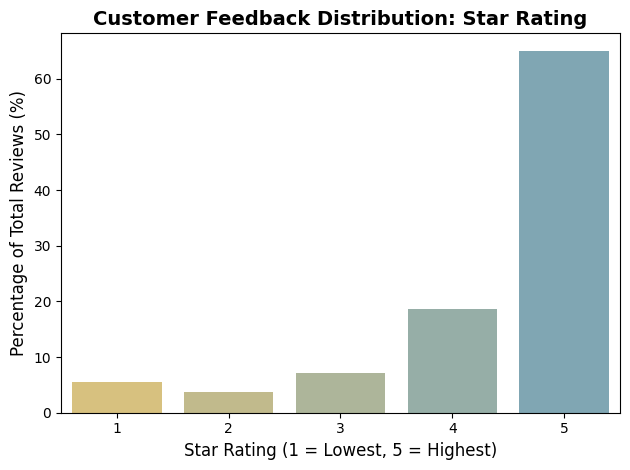

In [9]:
percentages = df['star_rating'].value_counts(normalize=True).sort_index() * 100

sns.barplot(x=percentages.index, y=percentages.values, hue=percentages.index, palette="blend:#e6c870,#7AB", legend=False)

plt.title("Customer Feedback Distribution: Star Rating", fontsize=14, fontweight='bold')
plt.xlabel("Star Rating (1 = Lowest, 5 = Highest)", fontsize=12)
plt.ylabel("Percentage of Total Reviews (%)", fontsize=12)

plt.tight_layout()
plt.savefig('star_rating_distribution.png', bbox_inches='tight',dpi=300)
plt.show()

In [10]:
# Q1. WHAT PERCENTAGE(%) OF REVIEWS ARE POSITIVE VS NEGATIVE?

sentiment_counts = df['sentiment'].value_counts()
sentiment_percentage = df['sentiment'].value_counts(normalize = True) * 100

print("Sentiment counts : ",sentiment_counts)
print("Sentiment Percentage : ",sentiment_percentage.round(2))

Sentiment counts :  sentiment
1    25763
0     5077
Name: count, dtype: int64
Sentiment Percentage :  sentiment
1    83.54
0    16.46
Name: proportion, dtype: float64


In [11]:
# Q2. WHICH PRODUCT HAVE HIGHEST SATISFACTION?

category_performance = df.groupby('product_id')['star_rating'].mean().reset_index()
category_performance.sort_values(by='star_rating', ascending = False)

,product_id,star_rating
12,B00LCHOCZY,4.516239
20,B00LCI3LUA,4.513514
19,B00LCI2I7C,4.494828
10,B00LCHNAA2,4.487923
13,B00LCHRQL6,4.475133
15,B00LCHSHMS,4.463054
14,B00LCHS1FG,4.445139
17,B00LCHWEPE,4.425971
0,B00IKPW0UA,4.355765
9,B00LCHN19C,4.355072


In [12]:
# Q3. COMMON WORDS IN 5-STAR VS 1-STAR REVIEWS?

from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

five_star_review = df[df['star_rating'] == 5]
one_star_review = df[df['star_rating'] ==1]

good_review = " ".join(five_star_review['cleaned_review']).split()
bad_review = " ".join(one_star_review['cleaned_review']).split()

good_words = [w for w in good_review
              if w not in ENGLISH_STOP_WORDS]
bad_words = [w for w in bad_review
             if w not in ENGLISH_STOP_WORDS]

print("Good Words : ", Counter(good_words).most_common(10))
print("Bad Words : ", Counter(bad_words).most_common(10))

Good Words :  [('love', 9230), ('kindle', 6263), ('great', 5153), ('use', 3130), ('tablet', 2856), ('hd', 2649), ('easy', 2300), ('like', 1933), ('new', 1768), ('just', 1673)]
Bad Words :  [('kindle', 1145), ('amazon', 886), ('device', 483), ('tablet', 426), ('just', 387), ('use', 381), ('new', 344), ('time', 329), ('buy', 319), ('apps', 319)]


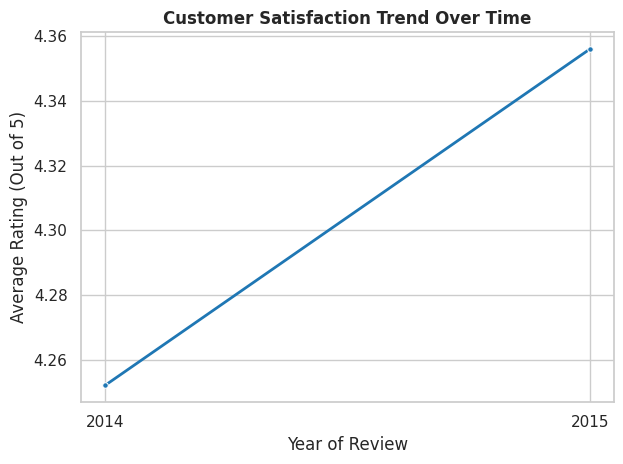

In [13]:
#Q4. SENTIMENT TRENDS OVER TIME?

df['review_date'] = pd.to_datetime(df['review_date'])
df['review_year'] = df['review_date'].dt.year

yearly_trends = df.groupby('review_year')['star_rating'].mean().reset_index()

sns.set_theme(style="whitegrid")

sns.lineplot(
    data = yearly_trends,
    x = 'review_year',
    y = 'star_rating',
    marker = 'o',
    markersize = 4,
    color = '#1f77b4',
    linewidth = 2
)

plt.title("Customer Satisfaction Trend Over Time", fontweight = 'bold')
plt.xlabel("Year of Review")
plt.ylabel("Average Rating (Out of 5)")

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('yearly_trend.png', bbox_inches = 'tight', dpi=300)
plt.show()

In [19]:
# MODEL FOR CLASSIFICATION PREDICTION

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.utils import resample

x = df['cleaned_review']
y = df['sentiment']

vectorizer = TfidfVectorizer(ngram_range=(1,2),stop_words = 'english')
x_vectorized = vectorizer.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_vectorized, y, test_size=0.2, random_state = 42)

model = LogisticRegression(class_weight = 'balanced')
model.fit(x_train, y_train)

accuracy = model.score(x_test, y_test)
print("Accuracy: ", accuracy)

y_pred = model.predict(x_test)
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

Accuracy:  0.8764591439688716
Confusion Matrix :  [[ 855  172]
 [ 590 4551]]
              precision    recall  f1-score   support

           0       0.59      0.83      0.69      1027
           1       0.96      0.89      0.92      5141

    accuracy                           0.88      6168
   macro avg       0.78      0.86      0.81      6168
weighted avg       0.90      0.88      0.88      6168



In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30840 entries, 0 to 30845
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   marketplace        30840 non-null  object        
 1   customer_id        30840 non-null  int64         
 2   review_id          30840 non-null  object        
 3   product_id         30840 non-null  object        
 4   product_parent     30840 non-null  int64         
 5   product_title      30840 non-null  object        
 6   product_category   30840 non-null  object        
 7   star_rating        30840 non-null  int64         
 8   helpful_votes      30840 non-null  int64         
 9   total_votes        30840 non-null  int64         
 10  vine               30840 non-null  object        
 11  verified_purchase  30840 non-null  object        
 12  review_headline    30840 non-null  object        
 13  review_body        30840 non-null  object        
 14  review_date

In [18]:
df.to_csv("cleaned_data.csv", index = False)